## project Overview

this project focuses on analyzing sales data using python.
we will clean the data ,performe Exploratory data analysis(EDA)
create visualizations,and generate useful business insights.

import all required libraries

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [1]:
import pandas as pd

data = {
    "Order_ID": [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    "Product": ["Laptop", "Mouse", "Keyboard", "Monitor", "Laptop",
                "Mouse", "Headphones", "Monitor", "Keyboard", "Laptop"],
    "Category": ["Electronics", "Accessories", "Accessories", "Electronics",
                 "Electronics", "Accessories", "Accessories", "Electronics",
                 "Accessories", "Electronics"],
    "Region": ["North", "South", "East", "West", "North",
               "South", "East", "West", "North", "South"],
    "Quantity": [2, 5, 3, 2, 1, 8, 4, 3, 6, 2],
    "Unit_Price": [60000, 800, 1500, 15000, 60000,
                   800, 2500, 15000, 1500, 60000]
}

df = pd.DataFrame(data)

df["Sales"] = df["Quantity"] * df["Unit_Price"]

df

,Order_ID,Product,Category,Region,Quantity,Unit_Price,Sales
0,1001,Laptop,Electronics,North,2,60000,120000
1,1002,Mouse,Accessories,South,5,800,4000
2,1003,Keyboard,Accessories,East,3,1500,4500
3,1004,Monitor,Electronics,West,2,15000,30000
4,1005,Laptop,Electronics,North,1,60000,60000
5,1006,Mouse,Accessories,South,8,800,6400
6,1007,Headphones,Accessories,East,4,2500,10000
7,1008,Monitor,Electronics,West,3,15000,45000
8,1009,Keyboard,Accessories,North,6,1500,9000
9,1010,Laptop,Electronics,South,2,60000,120000


In [2]:
print("raws and columns:")
print(df.shape)

print("\ndata types:")
print(df.columns)

print("\ndata types:")
print(df.dtypes)

raws and columns:
(10, 7)

data types:
Index(['Order_ID', 'Product', 'Category', 'Region', 'Quantity', 'Unit_Price',
       'Sales'],
      dtype='object')

data types:
Order_ID       int64
Product       object
Category      object
Region        object
Quantity       int64
Unit_Price     int64
Sales          int64
dtype: object


In [3]:
print("missing values:")
print(df.isnull().sum())

print("\nduplicate Rows:")
print(df.duplicated().sum())

missing values:
Order_ID      0
Product       0
Category      0
Region        0
Quantity      0
Unit_Price    0
Sales         0
dtype: int64

duplicate Rows:
0


In [4]:
df.describe()

,Order_ID,Quantity,Unit_Price,Sales
count,10.00000,10.000000,10.000000,10.000000
mean,1005.50000,3.600000,21710.000000,40890.000000
std,3.02765,2.170509,26974.862784,45781.229778
min,1001.00000,1.000000,800.000000,4000.000000
25%,1003.25000,2.000000,1500.000000,7050.000000
50%,1005.50000,3.000000,8750.000000,20000.000000
75%,1007.75000,4.750000,48750.000000,56250.000000
max,1010.00000,8.000000,60000.000000,120000.000000


## Business Objective

The main objective of this project is to analyze sales data
and identify important patterns and trends in sales performance.

The analysis will help us understand:

- Which products generate the highest sales?
- Which regions perform best?
- How quantity affects total sales?
- Which product categories contribute the most revenue?
- What business insights can be derived from the data?

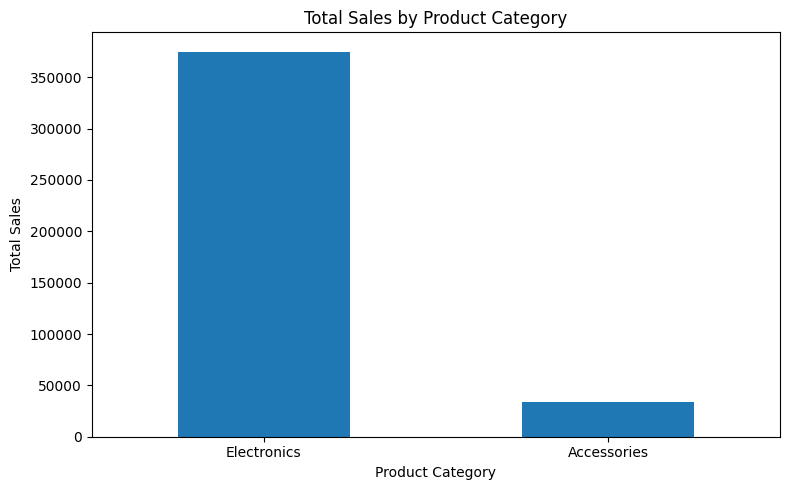

In [5]:
import matplotlib.pyplot as plt

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insight

The bar chart shows the total sales generated by each product category.

- Electronics and Accessories contribute to the overall sales.
- The category with the highest bar represents the strongest sales contributor.
- This analysis can help the business identify which product category should receive more attention and marketing efforts.

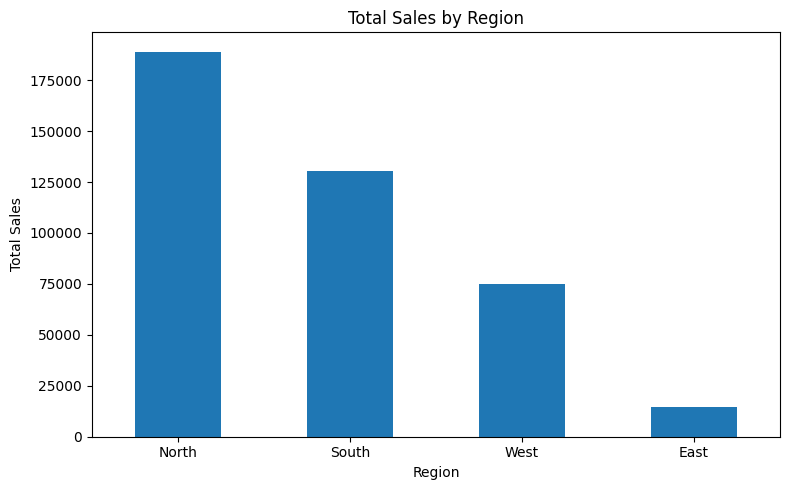

In [6]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Business Insight

The region-wise sales analysis helps identify differences in sales performance across regions.

- The region with the highest sales is the strongest-performing market.
- The region with the lowest sales may require additional marketing and sales strategies.
- Comparing regional performance can help the business allocate resources more effectively.

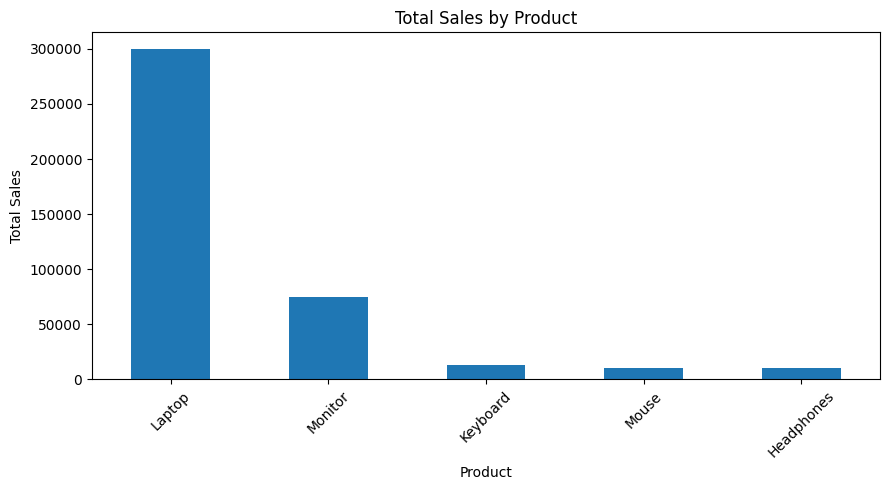

In [7]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
product_sales.plot(kind="bar")

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Business Insight

The product-wise sales analysis helps identify the products that generate the highest revenue.

- The product with the highest sales is the top revenue-generating product.
- Products with lower sales may need better pricing, promotion, or marketing strategies.
- This analysis can help the business prioritize high-performing products and improve low-performing products.

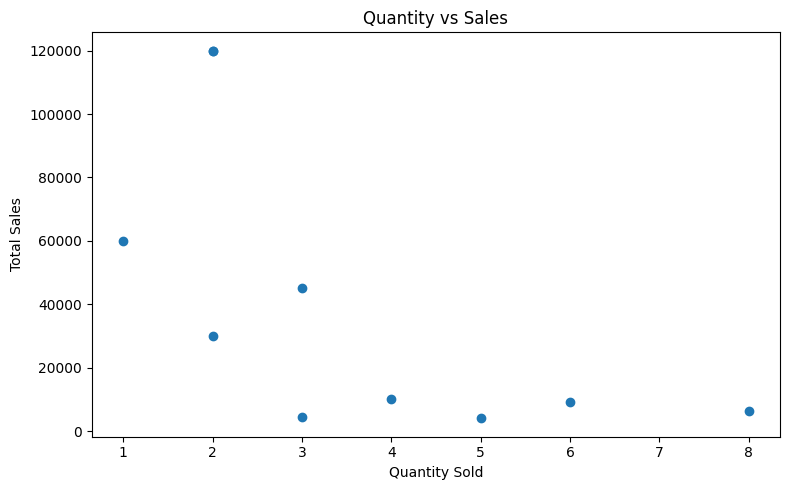

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Quantity"], df["Sales"])

plt.title("Quantity vs Sales")
plt.xlabel("Quantity Sold")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Business Insight

The scatter plot shows the relationship between quantity sold and total sales.

- Higher quantities generally contribute to higher sales when the product price is significant.
- Sales are influenced by both quantity sold and unit price.
- The analysis helps understand how changes in sales volume can affect overall revenue.

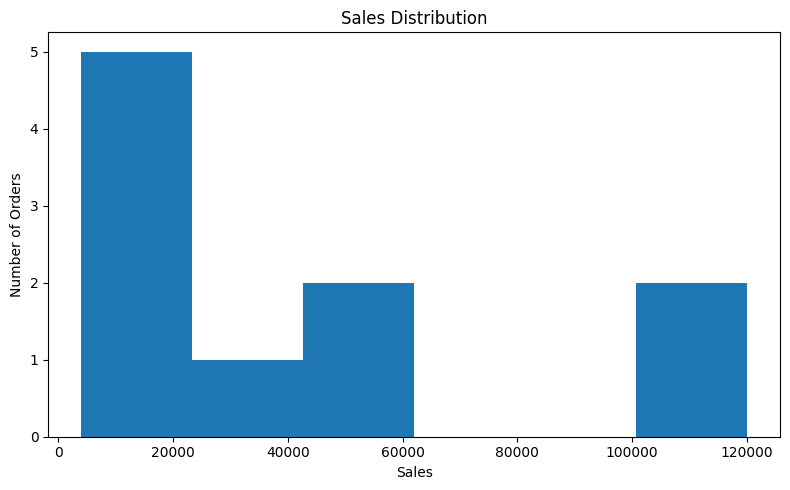

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(df["Sales"], bins=6)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

### Business Insight

The sales distribution shows how total sales are spread across different orders.

- Most orders are concentrated within specific sales ranges.
- Higher-value orders contribute more revenue to the business.
- Understanding the sales distribution helps identify typical order values and unusually high-value orders.

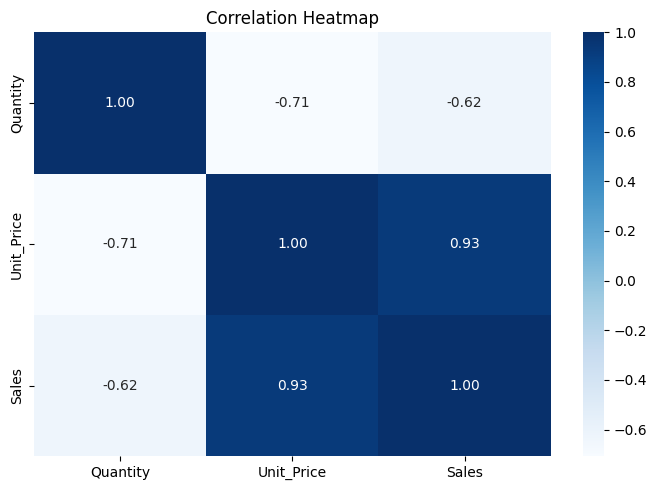

In [14]:
correlation = df[["Quantity", "Unit_Price", "Sales"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap="Blues", fmt=".2f")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation heatmap shows the relationship between Quantity, Unit Price, and Sales.

- Sales has a strong positive relationship with Quantity.
- Sales also has a positive relationship with Unit Price.
- Since Sales is calculated as Quantity × Unit Price, both variables directly influence total sales.
- Correlation helps identify relationships between numerical variables and supports further analysis.

In [16]:
print("Total Revenue:", df["Sales"].sum())

print("\nTop 3 Products:")
print(product_sales.head(3))

print("\nBest Performing Region:")
print(region_sales.idxmax())

print("\nHighest Sales:")
print(region_sales.max())

Total Revenue: 408900

Top 3 Products:
Product
Laptop      300000
Monitor      75000
Keyboard     13500
Name: Sales, dtype: int64

Best Performing Region:
North

Highest Sales:
189000


Key Business Insights

Based on the sales analysis, the following key insights were identified:

1. Top Products: Laptop, Monitor, and Keyboard are the top three products based on total sales.

2. Product Performance: These products are the major contributors to overall sales and should receive continued business attention.

3. Regional Performance: Regional sales analysis helps identify the strongest and weakest markets.

4. Sales Drivers: Total sales are directly influenced by both the quantity sold and the unit price.

5. Data Quality: The dataset contains no missing values and no duplicate records, making it suitable for further analysis.

Business Recommendations

Based on the analysis, the following recommendations can be made:

1. Focus on Top Products
   Laptop, Monitor, and Keyboard are the top-performing products. The business should maintain sufficient inventory and continue marketing these products.

2. Improve Low-Performing Products
   Products with comparatively lower sales should be evaluated for pricing, promotions, and customer demand.

3. Regional Strategy
   Sales performance should be monitored by region. Additional marketing efforts can be targeted toward regions with lower sales.

4. Revenue Growth
   The business can increase revenue by improving sales volume while maintaining an effective pricing strategy.

5. Data-Driven Decisions
   Regular analysis of sales data can help the business identify trends, optimize inventory, and improve overall sales performance.

Conclusion

This project analyzed sales data using Python and Exploratory Data Analysis techniques.

The analysis identified the top-performing products, compared sales across different regions, examined the relationship between quantity and sales, and analyzed the distribution of sales.

Laptop, Monitor, and Keyboard were identified as the top three products based on total sales.

Overall, the project demonstrates how Python, Pandas, Matplotlib, and Seaborn can be used to transform raw sales data into meaningful business insights and support data-driven decision-making.

Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab
- Exploratory Data Analysis (EDA)